# 篇末综合 有限证据与韧性判断

## 学习目标与先修知识

在有限规模（finite size）、级联、恢复和多尺度证据中限定结论。

先修：13.1—13.4；第4篇局部稳定、第11篇网络及第12篇个体模型（model）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一次有限群体扫描、一条网络级联轨迹（trajectory）和一个上升的预警指标，是否足以宣布“系统已经临界且韧性下降”？如何分别核对每项证据？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先把四项观察对应到不同模型对象：群体序参量（order parameter）、继发失效、扰动返回、粗尺度评分。避免把一个指标当成全部韧性。

In [2]:
labels=['有限规模序参量','同步阈值级联','局部恢复与过去窗口','粗/细尺度评分']
for i,label in enumerate(labels,1):print(i,label)

1 有限规模序参量
2 同步阈值级联
3 局部恢复与过去窗口
4 粗/细尺度评分


## 模型假设

每题独立给足参数（parameter）、输入（input）和评价时刻。群体为条件独立（conditional independence）二值同步更新（synchronous update）；级联为正整数阈值、不可逆同步失效；恢复为一维教学方程；预警为过去窗口，事件（event）标签用于独立评价；粗尺度比较固定共同指标。各题中的阈值分别由其更新规则和评价目标定义。

## 数学解释与推导

有限序参量需要 $(N,\beta,\text{暂态},\text{重复})$ 一起报告；级联用 $D_{t+1}=\{i:\#(N(i)\cap F_t)\ge k_i\}$；局部恢复率（local recovery rate） $a$ 不决定正向吸引域（basin of attraction）边界 $B$；AR(1) 的方差（variance）同时依赖 $\rho$ 与 $\sigma$。过去窗口在事件 $t$ 前截止；检出事件和误报（false alarm）报警按不同分母计。跨尺度干预排序反转（ranking reversal）提示结论依赖观测（observation）尺度。各项结论的适用条件必须分别写明。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def meanfield_step(spins, beta, draws):
    """Synchronous binary-choice update with supplied U[0,1) draws."""
    n = len(spins)
    magnetization = sum(spins) / n
    probability_plus = (1 + math.tanh(beta * magnetization)) / 2
    return [1 if draw < probability_plus else -1 for draw in draws]


def meanfield_path(initial, beta, draws_by_step):
    current = list(initial)
    magnetizations = [sum(current) / len(current)]
    for draws in draws_by_step:
        current = meanfield_step(current, beta, draws)
        magnetizations.append(sum(current) / len(current))
    return magnetizations


def order_summary(paths, burnin):
    """Tail mean |m| and between-repeat spread; no infinite-size claim."""
    values = [sum(abs(m) for m in path[burnin:]) / len(path[burnin:]) for path in paths]
    mean = sum(values) / len(values)
    spread = math.sqrt(sum((value - mean) ** 2 for value in values) / len(values))
    return [mean, spread]


def threshold_cascade(n, edges, thresholds, seeds):
    """Synchronous failed-neighbor count rule; rounds[0] is direct damage."""
    neighbors = [set() for _ in range(n)]
    for a, b in edges:
        neighbors[a].add(b)
        neighbors[b].add(a)
    failed = set(seeds)
    rounds = [sorted(failed)]
    while True:
        added = [i for i in range(n) if i not in failed
                 and sum(j in failed for j in neighbors[i]) >= thresholds[i]]
        if not added:
            return rounds
        failed.update(added)
        rounds.append(sorted(added))


def recovery_path(rate, boundary, initial, dt, steps):
    """Euler path for dx/dt=-rate*x*(1-x/boundary), positive initial only."""
    values = [float(initial)]
    for _ in range(steps):
        current = values[-1]
        values.append(current - dt * rate * current * (1 - current / boundary))
    return values


def past_window_stats(values, time_index, window, lag):
    """Population variance and fixed-sample-lag Pearson correlation, past only."""
    if time_index + 1 < window or lag < 1 or lag >= window:
        return [None, None]
    tail = values[time_index - window + 1:time_index + 1]
    mean = sum(tail) / window
    variance = sum((value - mean) ** 2 for value in tail) / window
    earlier, later = tail[:-lag], tail[lag:]
    mean_a = sum(earlier) / len(earlier)
    mean_b = sum(later) / len(later)
    centered_a = [value - mean_a for value in earlier]
    centered_b = [value - mean_b for value in later]
    denominator = math.sqrt(sum(x*x for x in centered_a) * sum(y*y for y in centered_b))
    correlation = sum(x*y for x, y in zip(centered_a, centered_b)) / denominator if denominator else None
    return [variance, correlation]


def alert_counts(alert_times, event_times, horizon):
    """Event-level detections, false alert times, missed events; no true-negative count."""
    alerts, events = set(alert_times), set(event_times)
    detected = sum(any(event - horizon <= alert < event for alert in alerts) for event in events)
    false_alerts = sum(not any(alert < event <= alert + horizon for event in events) for alert in alerts)
    return [detected, false_alerts, len(events) - detected]


def contrast_components(reference, parameter_only, observation_only, structure_only):
    """One-factor contrasts from a common reference, not variance components."""
    return [parameter_only - reference, observation_only - reference,
            structure_only - reference]


def scale_ranking(coarse_a, coarse_b, fine_a, fine_b):
    """Higher score is preferred; 0 is a tie, 1 favors A, -1 favors B."""
    def winner(a, b):
        return (a > b) - (a < b)
    coarse, fine = winner(coarse_a, coarse_b), winner(fine_a, fine_b)
    return [coarse, fine, coarse * fine == -1]

## 对照实验

使用固定随机输入和最小级联、有限扰动与尺度评分，让四种证据并列展示，但不强行汇成单一“韧性指数”。

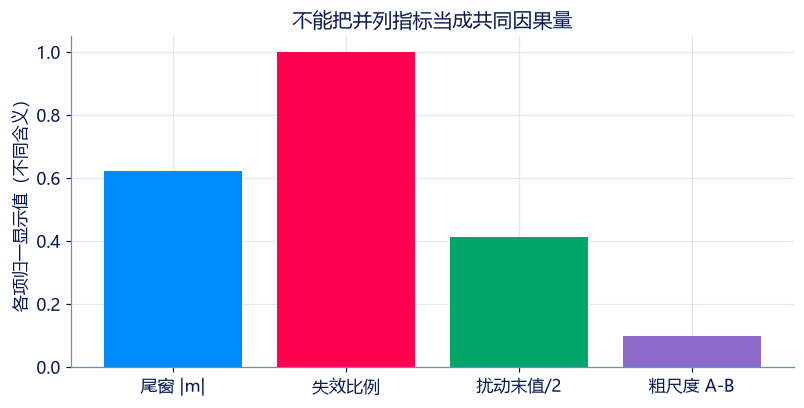

重复序参量 [0.6222222222222222, 0.05211099265563413] ；级联轮次 [[0], [1], [2], [3]] ；排序 [1, -1, True]


In [4]:
rng=np.random.default_rng(131300)
order=order_summary([meanfield_path([1]*50,1.2,rng.random((50,50))) for _ in range(5)],15)
waves=threshold_cascade(4,[[0,1],[1,2],[2,3]],[1]*4,[0])
recovery=recovery_path(1.5,2.,1.4,.02,40)
ranking=scale_ranking(.8,.7,.4,.6)
fig,ax=plt.subplots(figsize=(7.2,3.6))
ax.bar(['尾窗 |m|','失效比例','扰动末值/2','粗尺度 A-B'],
       [order[0],sum(map(len,waves))/4,recovery[-1]/2,.1],color=[BLUE,PINK,GREEN,'#8c69c9'])
ax.set(ylabel='各项归一显示值（不同含义）',title='不能把并列指标当成共同因果量')
plt.show()
print('重复序参量',order,'；级联轮次',waves,'；排序',ranking)

## 结果解释

图中各柱对应不同问题：规模影响群体波动，初始损伤影响级联，扰动大小影响返回，窗口和尺度影响评价。分别解释每个指标及其条件，再比较条件改变后的结果。

### 独立核对

核验无种子停止、过去窗口排除未来、级联总数及排序反转。

In [5]:
assert waves==[[0],[1],[2],[3]]
assert threshold_cascade(3,[[0,1],[1,2]],[1]*3,[])==[[]]
assert past_window_stats([0.,1.,2.,3.,1e6],3,4,1)==past_window_stats([0.,1.,2.,3.],3,4,1)
assert ranking==[1,-1,True]
print('四类证据边界核对通过。')

四类证据边界核对通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：有限规模的临界证据

三种规模各有重复轨迹（trajectory），有限观察窗中序参量（order parameter）曲线逐渐变陡。下一步最合适的结论是什么？

- **A.** 报告规模、暂态（transient）、重复不确定性和模型（model）条件，再研究是否能支持极限（limit）论断。
- **B.** 曲线变陡自动证明普适临界指数（critical exponent）。
- **C.** 只选一条最平滑轨迹作为代表。
- **D.** 有限随机模型必须没有任何固定点（fixed point）参照。

[作答：有限规模的临界证据](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-finite-claim)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：恢复速度与吸引域

两个系统在平衡（equilibrium）点附近的恢复率相同，一个正向吸引域（basin of attraction）边界为1，另一个为2；施加大小1.5的正扰动。哪项正确？

- **A.** 小扰动恢复速度相同，但1.5扰动可能只在第二个系统返回。
- **B.** 两个系统对所有扰动的命运相同。
- **C.** 第二个系统局部恢复率（local recovery rate）必为两倍。
- **D.** 吸引域只能从方差（variance）一项直接读出。

[作答：恢复速度与吸引域](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-basin)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：综合题：计算级联各轮

按题给无向网络与正整数阈值返回第0轮种子和各轮新增失效集合；不能把本轮新增节点立即纳入本轮邻居计数。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
    thresholds: list[int],
    seeds: list[int],
) -> list[list[int]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 原节点数。 | 节点 |
| `edges` | `list[list[int]]` | 无向边。 | 边 |
| `thresholds` | `list[int]` | 逐节点失效邻居数阈值，均至少1。 | 邻居 |
| `seeds` | `list[int]` | 初始直接损伤。 | 节点编号 |

**返回值**

直接返回 rounds（list[list[int]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rounds` | `list[list[int]]` | 逐轮新增失效，含第0轮。 | 节点编号 |

**计算规则**

同步轮次与不可逆失败，结果升序且无重复节点。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 原节点数。 | 5 | 节点 |
| edges | 无向边。 | [[0, 1], [1, 2], [2, 3], [3, 4]] | 边 |
| thresholds | 逐节点失效邻居数阈值，均至少1。 | [1, 1, 1, 1, 1] | 邻居 |
| seeds | 初始直接损伤。 | [0] | 节点编号 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 5
edges = [[0, 1], [1, 2], [2, 3], [3, 4]]
thresholds = [1, 1, 1, 1, 1]
seeds = [0]

result = solve(n, edges, thresholds, seeds)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rounds | 逐轮新增失效，含第0轮。 | [[0], [1], [2], [3], [4]] | 节点编号 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0], [1], [2], [3], [4]]
```

**样例解释**

直接损伤与继发失效分开；阈值高或无连接都可能阻断级联。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题：计算级联各轮](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-cascade)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：综合题：多次序参量摘要

按统一 burnin 对每条有符号序参量（order parameter）轨迹（trajectory）求尾窗 |m| 平均，再返回重复均值与重复间总体标准差（standard deviation）。

**函数与代码模板**

```python
def solve(
    paths: list[list[float]],
    burnin: int,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `paths` | `list[list[float]]` | 同一规模和参数（parameter）下的重复轨迹。 | 无量纲 |
| `burnin` | `int` | 舍弃的起始点数。 | 步 |

**返回值**

直接返回 summary（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `summary` | `list[float]` | 重复均值和重复间总体标准差。 | 无量纲 |

**计算规则**

必须先在每次重复内部汇总，不能先跨重复抵消正负号。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| paths | 同一规模和参数（parameter）下的重复轨迹。 | [[0.0, -0.6, -0.4], [0.0, 0.6, 0.4]] | 无量纲 |
| burnin | 舍弃的起始点数。 | 1 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
paths = [[0.0, -0.6, -0.4], [0.0, 0.6, 0.4]]
burnin = 1

result = solve(paths, burnin)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| summary | 重复均值和重复间总体标准差。 | [0.5, 0.0] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.5, 0.0]
```

**样例解释**

同等幅度的对称轨迹不会在绝对序参量中抵消。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题：多次序参量摘要](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-size-summary)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：综合题：无未来信息的预警窗

只用 time_index 及其以前的 window 个观测（observation），求总体方差（variance）和相隔 lag 个样本的相关；无法定义的相关返回 None。

**函数与代码模板**

```python
def solve(
    values: list[float],
    time_index: int,
    window: int,
    lag: int,
) -> list[float | None]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 全部观测，可能含尚不可用的未来值。 | 观测单位 |
| `time_index` | `int` | 当前末索引。 | 样本编号 |
| `window` | `int` | 过去窗口宽度。 | 样本 |
| `lag` | `int` | 滞后（lag）样本数。 | 样本 |

**返回值**

直接返回 indicators（list[float | None]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `indicators` | <code>list[float &#124; None]</code> | 方差和相关。 | 依输入单位²、无量纲 |

**计算规则**

窗口止于当前索引；未来极端值也不得改变当前结果。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 全部观测，可能含尚不可用的未来值。 | [1.0, 2.0, 3.0, 4.0, 100.0] | 观测单位 |
| time_index | 当前末索引。 | 3 | 样本编号 |
| window | 过去窗口宽度。 | 4 | 样本 |
| lag | 滞后（lag）样本数。 | 1 | 样本 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [1.0, 2.0, 3.0, 4.0, 100.0]
time_index = 3
window = 4
lag = 1

result = solve(values, time_index, window, lag)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| indicators | 方差和相关。 | [1.25, 1.0] | 依输入单位²、无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.25, 1.0]
```

**样例解释**

先固定评估时刻；恒定窗口相关分母为0，不能伪造零相关。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题：无未来信息的预警窗](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-past-window)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：综合题：不确定性单因素对照

在同一指标和单位下，分别只改变参数（parameter）、观测（observation）处理和结构，返回它们相对共同参考的有符号差。

**函数与代码模板**

```python
def solve(
    reference: float,
    parameter_only: float,
    observation_only: float,
    structure_only: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `reference` | `float` | 参考场景指标。 | 指标单位 |
| `parameter_only` | `float` | 仅改变参数的指标。 | 指标单位 |
| `observation_only` | `float` | 仅改变观测处理的指标。 | 指标单位 |
| `structure_only` | `float` | 仅改变模型结构（model structure）的指标。 | 指标单位 |

**返回值**

直接返回 differences（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `differences` | `list[float]` | 参数、观测和结构的三个有符号差。 | 指标单位 |

**计算规则**

三项都使用同一参考；无需假设它们独立可加。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| reference | 参考场景指标。 | 0.5 | 指标单位 |
| parameter_only | 仅改变参数的指标。 | 0.6 | 指标单位 |
| observation_only | 仅改变观测处理的指标。 | 0.4 | 指标单位 |
| structure_only | 仅改变模型结构（model structure）的指标。 | 0.9 | 指标单位 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
reference = 0.5
parameter_only = 0.6
observation_only = 0.4
structure_only = 0.9

result = solve(reference, parameter_only, observation_only, structure_only)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| differences | 参数、观测和结构的三个有符号差。 | [0.09999999999999998, -0.09999999999999998, 0.4] | 指标单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.09999999999999998,
                   -0.09999999999999998,
                   0.4]
```

**样例解释**

分别报告来源；相加需要另外检验交互，而不是默认成立。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题：不确定性单因素对照](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-uncertainty)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：综合题：误报和漏报

一个事件（event）在前 horizon 个离散时刻内至少有一次预警即算被检出；没有任何后续事件落入窗口的预警为误报（false alarm）。返回检出事件数、误报预警数、漏报（missed event）事件数。

**函数与代码模板**

```python
def solve(
    alert_times: list[int],
    event_times: list[int],
    horizon: int,
) -> list[int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `alert_times` | `list[int]` | 报警时刻，按集合语义去重。 | 时刻 |
| `event_times` | `list[int]` | 真实转变时刻，按集合语义去重。 | 时刻 |
| `horizon` | `int` | 报警后的预测窗口长度，正整数。 | 步 |

**返回值**

直接返回 counts（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `counts` | `list[int]` | 检出事件、误报预警、漏报事件的个数。 | 个 |

**计算规则**

事件发生当刻的报警不算提前预警；一项报警可覆盖窗口内事件，但误报按报警次数计。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| alert_times | 报警时刻，按集合语义去重。 | [2, 4, 8] | 时刻 |
| event_times | 真实转变时刻，按集合语义去重。 | [5, 12] | 时刻 |
| horizon | 报警后的预测窗口长度，正整数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
alert_times = [2, 4, 8]
event_times = [5, 12]
horizon = 2

result = solve(alert_times, event_times, horizon)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| counts | 检出事件、误报预警、漏报事件的个数。 | [1, 2, 1] | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1, 2, 1]
```

**样例解释**

先固定事件、时刻和窗口，再分开计事件级检出与报警级误报。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合题：误报和漏报](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-alert-errors)

### 第 8 题 · 迁移挑战 · 10 分 · 单项选择题：改变尺度后的韧性结论

某干预在一个有限网络上减少级联，却在粗尺度恢复指标上无改进，预警还出现误报（false alarm）。哪项结论有依据？

- **A.** 分别报告指标、尺度和条件，不能把一种优势推广成全面韧性提升。
- **B.** 只要级联更少，就证明所有韧性指标提高。
- **C.** 误报可以从结果表中删除。
- **D.** 有限网络结果自动适用于任意结构和规模。

[作答：改变尺度后的韧性结论](http://127.0.0.1:8000/parts/13-%E4%B8%B4%E7%95%8C%E5%8F%98%E5%8C%96%E4%B8%8E%E9%9F%A7%E6%80%A7/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p13-capstone-scale-limit)

**进一步阅读**

[SFI Complexity Explorer](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)、[Network Science](https://networksciencebook.com/translations/en/partials/chapter.html)和[Scheffer 等（2009）](https://www.nature.com/articles/nature08227)分别为尺度、网络和预警提供延伸阅读。